# SwarmRules v1.0

**Ferienakademie 2026 — Learning Rules for Life-Like Emergent Behavior**

## Shared project: local rules, collective behavior

Every agent in the simulation executes the **same local rule**. An individual agent sees only a small part of the world, has a small persistent memory, and can move, push cargo, and interact with pheromone fields.

The project is called **SwarmRules**. The Python module name remains `fa2026`, so the examples use `import fa2026 as fa`.

Your task is not to command the swarm from above. Instead, design a local rule from which useful collective behavior emerges.

This notebook is both the starting point for the project and a compact reference for the student-facing API.


## 1. The complete interface

The framework is imported once:

```python
import fa2026 as fa
```

You write one function:

```python
def rule(observation, memory):
    ...
    return action, new_memory
```

and run it with, for example:

```python
fa.run("gather", rule, seed=1, visualize=True)
```

All agents use the same `rule`. There are no agent IDs and no global controller.

You can inspect the public specification of a scenario at any time with `fa.info(...)`.


In [1]:
import numpy as np
import fa2026 as fa
from main_shark import shark_rule
from rules import following_wall_rule, RULES

print("fa2026 version:", fa.__version__)

fa2026 version: 1.0.0


## 2. Inspect the scenario

Before writing a rule, ask the framework for the fixed rules and parameters of the task:

```python
fa.info("gather")
```

This reports the goal, arena and population sizes, sensing and memory resources, energy/recharge, pheromone decay, action costs, cargo mobility where relevant, and which parts of the initial geometry depend on the seed. It does **not** reveal the actual target or cargo coordinates for a particular seed.


In [2]:
fa.info("gather")


Scenario: gather — Search and gather

Goal
  All 100 agent points must be inside the target simultaneously.
  Score: turns until success

World
  Arena: 64 x 48 cells (width x height)
  Agents: 100
  Agent initialization: 100 agents sampled in a loose central region.
  Cargoes: 0
  Cargo setup: None.
  Target: 5 cells deep x 12 cells along one arena boundary; side and offset are randomized.
  Randomized by seed: target side/position and all agent positions

Agent resources
  Vision radius: 4 cells (9 x 9 local patch)
  Memory: 8 floats per agent
  Battery capacity: 24
  Recharge per turn: 0.45

Pheromones
  Channels: 1
  Channel 0 decay fraction per turn: 0.01
  Sensing: local 3 x 3 concentration patch per channel

Action rules and energy
  Push: finite p >= 0; cost p^2; effective only while the agent is inside a cargo
        direction is automatic: from the agent toward that cargo's center
  Move: finite (dx, dy); cost dx^2 + dy^2; walls stop motion
  Pheromone q > 0: deposit at the 

## 3. What does one agent know?

For each turn, `observation` contains five pieces of local information.

### `observation.energy`
Current battery energy, after automatic recharge at the beginning of the turn.

### `observation.cell_position`
The fractional `(x, y)` position inside the agent's current grid cell. Each coordinate lies in `[0, 1)`. This helps with continuous movement, but **does not reveal an absolute world position**.

### `observation.vision`
A square local grid patch centered on the current cell. Its entries are bit flags:

```python
fa.Cell.EMPTY
fa.Cell.WALL
fa.Cell.TARGET
fa.Cell.CARGO
```

Flags may be combined. For example, a cargo inside the target may have both `CARGO` and `TARGET` set. Walls do not block vision.

### `observation.pheromones`
For each available pheromone channel, the agent receives a local `3 × 3` concentration patch. In the introductory scenarios there is one channel.

### `observation.on_cargo`
`True` when the point agent currently lies inside a cargo and can therefore push it this turn.

The agent does **not** receive its absolute position, a turn counter, an ID, the complete map, cargo IDs, or direct information about other agents.


## 4. Memory

The second argument, `memory`, is a one-dimensional numeric array belonging to this agent alone.

- It starts with all entries equal to zero.
- Only the `new_memory` returned by your rule survives to the next turn.
- The introductory scenarios provide 8 memory values per agent.

You decide what those values mean. They could store, for example, a direction, a mode, a timer, or estimates learned from previous turns.

Memory is the only intended persistent internal state of an agent.


## 5. What can an agent do?

Return an `fa.Action` containing push, movement, and pheromone requests:

```python
fa.Action(
    push=p,
    move=(dx, dy),
    pheromones=(q0, q1, ...),
)
```

All fields default to zero action. For example, `fa.Action(move=(dx, dy))` means “move only”.

### Push
`push` is a non-negative scalar. It only has an effect if `observation.on_cargo` is true. The force direction is automatic: **from the agent toward the center of the cargo it occupies**. Therefore useful pushing depends on where the agent positions itself inside the cargo.

### Move
`move=(dx, dy)` is a continuous requested displacement. Walls stop agents; cargoes and other agents do not.

### Pheromones
For channel `k`:

- `q_k > 0`: deposit pheromone at the **new position** after movement;
- `q_k = 0`: do nothing;
- `q_k < 0`: request uptake from the **old position** before pushing/moving.

Negative uptake is processed before push/move, while positive deposition happens after movement. Pheromones can therefore be used as communication and, later, even as spatial energy storage.


## 6. Energy and turn order

Movement and pushing have quadratic energy costs:

\[
E_{\rm move}=dx^2+dy^2,\qquad E_{\rm push}=p^2.
\]

Depositing pheromone concentration `q` in a channel with decay fraction `d` costs `q/d`. Batteries recharge automatically each turn.

The full turn order is:

1. recharge;
2. observe;
3. evaluate all rules;
4. take up old pheromone at the current position;
5. check whether the outgoing action is affordable;
6. push cargoes;
7. move cargoes;
8. move agents;
9. decay old pheromone and add new deposits;
10. store new memory;
11. test success.

If an outgoing action is unaffordable, its push, move, and positive pheromone deposition are rejected rather than automatically rescaled.


## 7. A deliberately weak starting rule

The following controller is intentionally almost strategy-free. It is a small Monte-Carlo example whose only purpose is to show the **complete input/output interface** in action.

It ignores `observation`, returns `memory` unchanged, and independently requests a random push, a random two-dimensional move, and a random positive pheromone deposit. Most pushes are useless in `gather`, the pheromone has no meaning, and the agents do not react to walls or the target.

The controller uses its own seeded NumPy random-number generator. This RNG is separate from the scenario `seed=` used by `fa.run`.


In [3]:
rng = np.random.default_rng(1)


def rule(observation, memory):
    # pick rule
    return following_wall_rule(observation, memory)
    return shark_rule(observation, memory)


## 8. Run Scenario 1: `gather`

`gather` contains many agents, no cargo, low visibility, and a small target randomly placed along one boundary. All agents must be inside the target simultaneously.

The random rule above is deliberately ineffective. We put a finite limit on this first demonstration so it cannot run forever. During normal work you can omit `max_turns` and interrupt an unsuccessful run yourself.

Resetting `rng` before the run makes the controller's random choices reproducible. Set `visualize=True` when you want to watch the swarm.


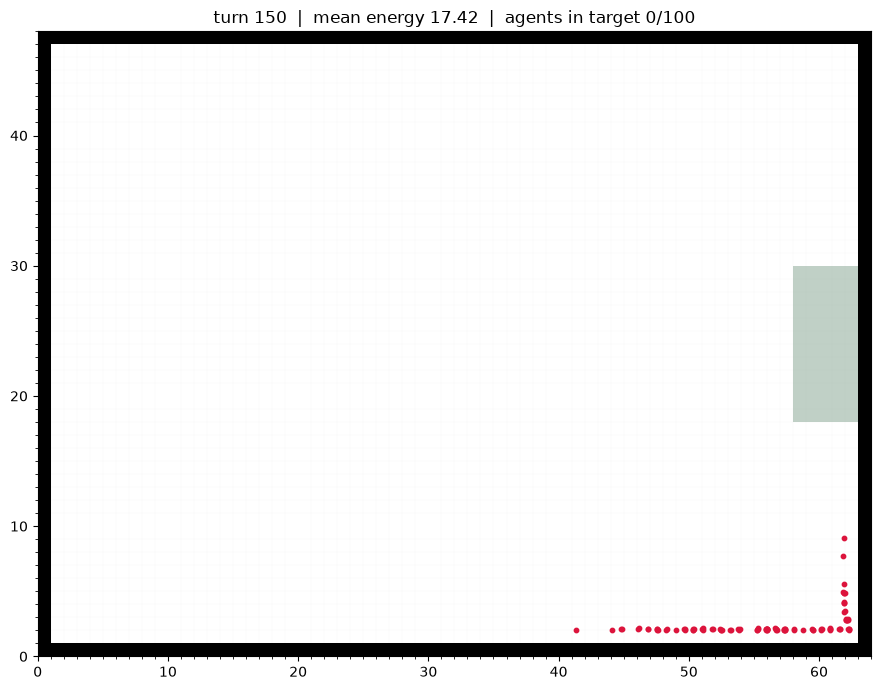

Result(success=False, turns=150)

In [ ]:
rng = np.random.default_rng(1)

result = fa.run(
    "gather",
    rule,
    seed=1,
    visualize=True,
    draw_every=2,      # draw every second turn for a smoother demo
    max_turns=500,
)
result

## 9. Seeds are part of the task

The mechanics and physical parameters of `gather` stay fixed, but the scenario seed changes the initial geometry, including the target and agent positions.

The controller RNG is independent. In the comparison below we reset it to the same state before every run, so only the **scenario geometry** changes between seeds.


In [5]:
for seed in (1, 2, 3):
    rng = np.random.default_rng(1)  # same controller randomness for each geometry
    result = fa.run(
        "gather",
        rule,
        seed=seed,
        visualize=False,
        max_turns=100,
    )
    print(f"seed {seed}: {result}")


seed 1: Result(success=False, turns=100)
seed 2: Result(success=False, turns=100)
seed 3: Result(success=False, turns=100)


## 10. The three introductory scenarios

### Scenario 1 — `gather`
**Goal:** all agents enter the target simultaneously.

The arena is large and open, vision is short-ranged, and the target is randomly placed at a boundary. A simple exploration strategy can eventually work, but collective guidance should be much more effective.

Questions to think about:

- How can different agents explore different parts of the arena?
- What should an agent do after it finds the target?
- Can a pheromone field communicate a direction rather than only “something happened here”?
- How can successful agents help agents that are still lost?

### Scenario 2 — `transport`
**Goal:** move one slow cargo into the target.

The target direction is deliberately easier to determine than in Scenario 3. The main challenge is collective transport.

Questions to think about:

- How do agents find and recruit around the cargo?
- Where inside the cargo should an agent stand if it wants to push in a desired direction?
- How can agents keep following a moving cargo?
- How does performance change with the number of agents pushing together?

### Scenario 3 — `communicate`
**Goal:** move one slow cargo into a target that is initially outside the cargo workers' visual range.

This combines the previous ideas. Information about the target has to reach agents involved in transport.

There is no single intended solution. The point is to invent and compare local rules that generate useful collective behavior.

For the authoritative fixed parameters, use:

```python
fa.info()
fa.info("gather")
fa.info("transport")
fa.info("communicate")
```


## 11. Fast iteration

Visualization is useful for understanding behavior, but headless runs are much faster:

```python
result = fa.run(
    "gather",
    rule,
    seed=1,
    visualize=False,
    max_turns=500,
)
```

The score is simply the number of turns until success. During development, `max_turns` is only a convenient safeguard. You can omit it and interrupt a run once you decide the current rule is not useful.

A good workflow is:

1. watch one seed with visualization;
2. identify a behavioral problem;
3. change the local rule;
4. test headlessly on several seeds;
5. visualize again when the behavior surprises you.


## 12. What to edit

For the first exercises, you normally only need to edit your `rule()` function and any helper functions/constants that it uses.

The framework deliberately exposes the introductory scenario source code. You are free to understand the environment precisely. The challenge is to create robust **local collective behavior**, not to guess hidden constants.

Later stages of the project may use additional scenarios, parameter variation, optimization methods, and teacher-side evaluation seeds.
